In [8]:
import nltk 

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [10]:
df = pd.read_csv("all_kindle_review .csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [11]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'asin', 'helpful', 'rating', 'reviewText',
       'reviewTime', 'reviewerID', 'reviewerName', 'summary',
       'unixReviewTime'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    12000 non-null  int64 
 1   Unnamed: 0      12000 non-null  int64 
 2   asin            12000 non-null  object
 3   helpful         12000 non-null  object
 4   rating          12000 non-null  int64 
 5   reviewText      12000 non-null  object
 6   reviewTime      12000 non-null  object
 7   reviewerID      12000 non-null  object
 8   reviewerName    11962 non-null  object
 9   summary         11998 non-null  object
 10  unixReviewTime  12000 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 1.0+ MB


In [13]:
df1 = df.copy()

In [14]:
def preprocess_for_cnn(text):
    if pd.isna(text):
        return ""
        
    # Convert to string (actual input)
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
   
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtag symbol but keep word
    text = re.sub(r'#', '', text)

    # Lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
df1['clean_text'] = df1['reviewText'].apply(preprocess_for_cnn)

In [16]:
#Define labels
df1['labels'] = df1['rating'].apply(
    lambda x: 1 if x >= 4 else 0
)

In [17]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    df1['clean_text'],
    df1['labels'],
    test_size=0.2,
    random_state=42
)

In [18]:
#Tokenization 
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text → sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [19]:
#Padding
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

In [20]:
print(X_train_pad.shape, X_test_pad.shape)
print(y_train.shape, y_test.shape)

(9600, 100) (2400, 100)
(9600,) (2400,)


In [21]:
#Label Encoding
y_train = np.array(y_train)
y_test = np.array(y_test)

In [22]:
import torch
import torch.nn as nn

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1) # Change shape for Conv1d
        x = torch.relu(self.conv1(x))
        x = self.pool(x).squeeze(2)
        return self.fc(x)

# Initialize
model = TextCNN(vocab_size=5000, embed_dim=128, num_classes=3)
print(model)

TextCNN(
  (embedding): Embedding(5000, 128)
  (conv1): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [23]:
import torch
import torch.nn as nn

class Text2DCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, seq_len, num_classes):
        super(Text2DCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # Conv2d expects input: (Batch, Channels, Height, Width)
        # Here: Channels=1, Height=seq_len, Width=embed_dim
        self.conv2d = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, embed_dim))
        self.fc = nn.Linear(32 * (seq_len - 3 + 1), num_classes)
        
    def forward(self, x):
        # x shape: (Batch, Seq_Len)
        x = self.embedding(x).unsqueeze(1) # Add channel dim: (Batch, 1, Seq_Len, Embed_Dim)
        x = torch.relu(self.conv2d(x)).squeeze(3) # Shape: (Batch, 32, Seq_Len - kernel + 1)
        x = torch.flatten(x, 1)
        return self.fc(x)

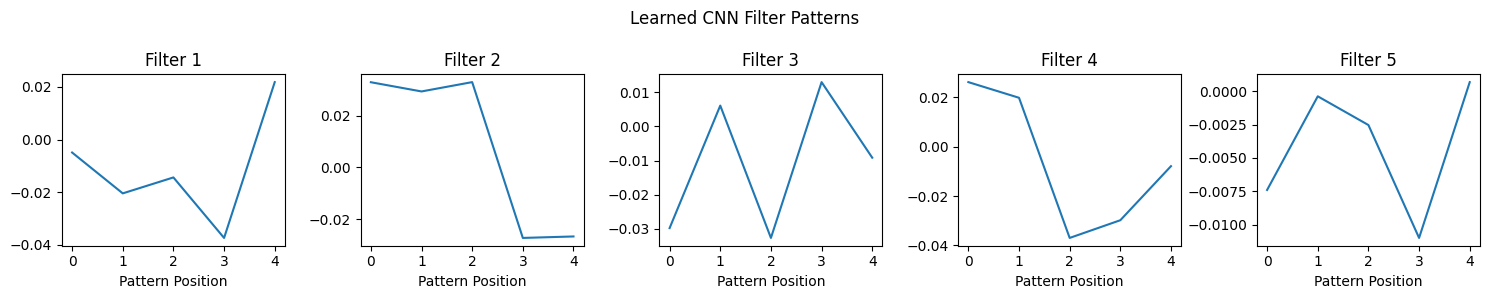

In [24]:
import matplotlib.pyplot as plt

conv_layer = model.conv1 
weights = conv_layer.weight.data.cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Filters are shaped [out_channels, in_channels, kernel_size]
    axes[i].plot(weights[i, 0, :])
    axes[i].set_title(f"Filter {i+1}")
    axes[i].set_xlabel("Pattern Position")

plt.suptitle("Learned CNN Filter Patterns")
plt.tight_layout() 
plt.show()

In [27]:
from torch.utils.data import DataLoader, TensorDataset
import torch

# 1. Convert your X_train/y_train to Tensors if they aren't already
# (Ensure your X_train is a LongTensor for the embedding layer)
train_dataset = TensorDataset(torch.LongTensor(X_train_pad), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.LongTensor(X_test_pad), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
val_dataset = TensorDataset(torch.LongTensor(X_test_pad), torch.LongTensor(y_test))

# 2. Define the loaders
# 'batch_size' controls how many reviews are processed at once
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [31]:
import optuna
import torch.optim as optim

# 1. Ensure these are defined globally based on your previous preprocessing
# VOCAB_SIZE = ... (the max index + 1 from your tokenizer)
# train_loader = ... 
# val_loader = ... 
# val_dataset = ...

def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    
    # Initialize model inside the function
    # Ensure num_classes matches your 3 labels (Negative, Neutral, Positive)
    model = TextCNN(vocab_size=VOCAB_SIZE, embed_dim=128, num_classes=3)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Train for 5 epochs
    model.train()
    for epoch in range(5):
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    return correct / total # Return accuracy

# 2. Create the study
study = optuna.create_study(direction="maximize")

# 3. Run the search
print("Starting Optuna search...")
study.optimize(objective, n_trials=10)

# 4. Print results
print(f"Best trial: {study.best_trial.value}")
print(f"Best Learning Rate: {study.best_params['lr']}")
print(f"Best Dropout: {study.best_params['dropout']}")






[I 2026-06-26 04:47:21,653] A new study created in memory with name: no-name-633536ec-ce2b-4f5d-a4c5-278f9999b1fe


Starting Optuna search...


[I 2026-06-26 04:47:45,052] Trial 0 finished with value: 0.7145833333333333 and parameters: {'lr': 5.797125244038374e-05, 'dropout': 0.35654998054475706}. Best is trial 0 with value: 0.7145833333333333.
[I 2026-06-26 04:48:09,136] Trial 1 finished with value: 0.7916666666666666 and parameters: {'lr': 0.002771622851507652, 'dropout': 0.17733173721453546}. Best is trial 1 with value: 0.7916666666666666.
[I 2026-06-26 04:48:32,778] Trial 2 finished with value: 0.7854166666666667 and parameters: {'lr': 0.0008731624799362643, 'dropout': 0.14644033839553627}. Best is trial 1 with value: 0.7916666666666666.
[I 2026-06-26 04:48:56,645] Trial 3 finished with value: 0.75 and parameters: {'lr': 7.011255289134132e-05, 'dropout': 0.20967025209841395}. Best is trial 1 with value: 0.7916666666666666.
[I 2026-06-26 04:49:21,580] Trial 4 finished with value: 0.7970833333333334 and parameters: {'lr': 0.002689313089595647, 'dropout': 0.46697443112302417}. Best is trial 4 with value: 0.7970833333333334.
[

Best trial: 0.7970833333333334
Best Learning Rate: 0.002689313089595647
Best Dropout: 0.46697443112302417


In [43]:
best_lr = study.best_params['lr']
final_model = TextCNN(vocab_size=5000, embed_dim=128, num_classes=3)
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)

# Store history for visualization
history = {'loss': [], 'acc': []}

for epoch in range(5):
    # ... your training loop ...
    # history['loss'].append(epoch_loss)
    # history['acc'].append(epoch_acc)
    print(f"Epoch {epoch+1}/5 complete.")

Epoch 1/5 complete.
Epoch 2/5 complete.
Epoch 3/5 complete.
Epoch 4/5 complete.
Epoch 5/5 complete.


Epoch 1 finished.
Epoch 2 finished.
Epoch 3 finished.
Epoch 4 finished.
Epoch 5 finished.


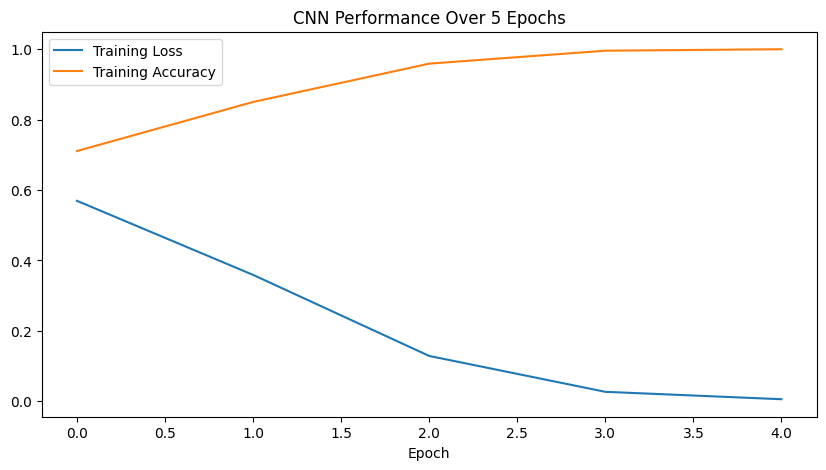

In [44]:
# 1. Initialize lists for tracking
loss_list = []
acc_list = []

final_model = TextCNN(vocab_size=VOCAB_SIZE, embed_dim=128, num_classes=3)
optimizer = optim.Adam(final_model.parameters(), lr=0.002689313089595647)
criterion = nn.CrossEntropyLoss()

# 2. Run the loop
final_model.train()
for epoch in range(5):
    epoch_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Calculate stats
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Manually append to lists
    loss_list.append(epoch_loss / len(train_loader))
    acc_list.append(correct / total)
    print(f"Epoch {epoch+1} finished.")

# 3. Plotting
plt.figure(figsize=(10, 5))
plt.plot(loss_list, label='Training Loss')
plt.plot(acc_list, label='Training Accuracy')
plt.title("CNN Performance Over 5 Epochs")
plt.xlabel("Epoch")
plt.legend()
plt.show()